## Imports and utilitaries

Run all cells in this section before simulating.


In [2]:
# copied from all_possible_paths.py
 
### In this script I can try all the different combinations of actions for the AV agents.
import itertools
import os
import pandas as pd
import numpy as np
import csv
import torch
from tensordict.nn import TensorDictModule, TensorDictSequential
from torchrl.envs.libs.pettingzoo import PettingZooWrapper
from torchrl.envs.transforms import TransformedEnv, RewardSum
from torchrl.envs.utils import check_env_specs
from torch import nn
from torchrl._utils import logger as torchrl_logger
from torchrl.collectors import SyncDataCollector
from torchrl.data import TensorDictReplayBuffer
from torchrl.data.replay_buffers.samplers import SamplerWithoutReplacement
from torchrl.data.replay_buffers.storages import LazyTensorStorage
from torchrl.modules import EGreedyModule, QValueModule, SafeSequential
from torchrl.modules.models.multiagent import MultiAgentMLP
from torchrl.objectives import SoftUpdate, ValueEstimators, DQNLoss

from routerl import TrafficEnvironment

from routerl.keychain import Keychain as kc
from routerl.utilities import get_params

os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import matplotlib.pyplot as plt

In [ ]:
def update_trafficlight(t0,t1,ty):

    # template file
    read_file_name = "../networks/two_route_trafficlight/two_route_trafficlight.net.xml"

    # path within the RouteRL module
    write_file_name = "C:/Users/Utilisateur/AppData/Local/Packages/PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0/LocalCache/local-packages/Python313/site-packages/routerl/networks/two_route_trafficlight/two_route_trafficlight.net.xml"
    
    # path within the /networks/ folder
    network_file_name = "../networks/two_route_trafficlight/two_route_trafficlight.net.xml"

    tllogic = []
    tllogic.append( "\t<tlLogic id=\"J2\" type=\"static\" programID=\"0\" offset=\"0\">\n")
    tllogic.append( "\t\t<phase duration=\"%s\" state=\"Gr\"/>\n"%(t1))
    tllogic.append( "\t\t<phase duration=\"%s\"  state=\"yr\"/>\n"%(ty))
    tllogic.append( "\t\t<phase duration=\"%s\" state=\"rG\"/>\n"%(t0))
    tllogic.append( "\t\t<phase duration=\"%s\"  state=\"ry\"/>\n"%(ty))
    tllogic.append( "\t</tlLogic>\n")

    with open(read_file_name, "r") as fr:
        lines = fr.readlines()
        print(lines)

    with open(write_file_name, "w") as fw:
        fw.writelines(lines[:76])
        fw.writelines(tllogic)
        fw.writelines(lines[82:])

    with open(network_file_name, "w") as fw:
        fw.writelines(lines[:76])
        fw.writelines(tllogic)
        fw.writelines(lines[82:])
    
    return None

def create_environment(nb_agents=23):
    env = TrafficEnvironment(
        agent_parameters={
            "num_agents": nb_agents, 
            "new_machines_after_mutation": 10, 
            "machine_parameters": {
                "behavior": "selfish"
                }
            },
        simulator_parameters={
            "network_name": "two_route_trafficlight",
            "sumo_type": "sumo"
            },
        path_generation_parameters={
            "origins": ["E0"],
            "destinations": ["E2"],
            "number_of_paths": 2
            }
        )
    return env

def simulate(nb_agents=23):

    env = create_environment(nb_agents)
    env.start()
    env.mutation()

    actions = [0, 1]
    print("env.human_agents", env.human_agents)
    print("env.machine_agents", env.machine_agents)
    print("\n")

    env.reset()

    i = 0
    k = 1
    for combination in itertools.product(actions, repeat=len(env.possible_agents)):
        i += 1
        for action in combination:
            env.step(action)
        if i > k*1024/10:
            print("%s combinations out of 1024 tested, %s%s remaining"%(i,(10-k)*10,"%"))
            k += 1

        env.reset()
    
    env.stop_simulation()

def build_df(i):
    df = pd.read_csv("training_records/episodes/ep"+str(i)+".csv")
    df = df[df["kind"] == "AV"]
    df = df.sort_values(by="start_time").reset_index(drop=True)
    df["reward"] = -1*df["travel_time"]
    df = df[["reward","action"]]
    return df

def write_line(i,df):
    line = str(i)
    for i in range(10):
        line = line + "," + str(df["reward"].values[i])
    return line

def record_experiment(file_name):
    with open(file_name, "w") as f:
        f.write("id,0,1,2,3,4,5,6,7,8,9\n")
        for i in range(1024):
            data = build_df(i+1)
            text = write_line(i,data)
            f.write(text+"\n")

In [ ]:
def id_to_strategy(id):
    strategy = [0 for _ in range(10)]
    i = 0
    while id > 0:
        if id % 2 == 1:
            strategy[9-i] = 1
        id = id//2
        i += 1
    return strategy

def strategy_to_id(s):
    id = 0
    for i in range(10):
        id += s[i]*(2**(9-i))
    return id

def coalition_to_strategy(coalition):
    s = [0 for _ in range(10)]
    for i in coalition:
        s[i] = 1
    return s

def strategy_to_coalition(s):
    coalition = []
    for i in range(10):
        if s[i] == 1:
            coalition.append(i)
    return coalition

def build_rewardtable(file_name):
    df_reward = pd.read_csv(file_name)
    tab = np.zeros((10,1024))
    for i in range(10):
        tab[i] = df_reward[str(i)].values
    return tab

def custom_df(tl_list, custom_filename = "reward_df_custom.csv"):

    assert len(tl_list) == 11

    f = open(custom_filename,"w")
    
    f.write("id,0,1,2,3,4,5,6,7,8,9\n")
    for id in range(1024):

        s = id_to_strategy(id)
        n_1 = 0
        for j in range(10):
            n_1 += s[j]
        tl_0,tl_1,tl_y,nb_agents = tl_list[n_1]

        try:
            df_reward = pd.read_csv("reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1,tl_y,nb_agents))
        except:
            print("Reward table for tl_0 = %s, tl_1 = %s, tl_y = %s and %s agents was not found. Running..."%(tl_0,tl_1,tl_y,nb_agents))
            run(tl_0,tl_1,tl_y,nb_agents)
            df_reward = pd.read_csv("reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1,tl_y,nb_agents))

        text = str(id)
        tab_reward = [[] for _ in range(10)]
        for i in range(10):
            tab_reward[i] = df_reward[str(i)].values
            text = text + "," + str(float(tab_reward[i][id]))

        f.write(text+"\n")

In [30]:
def reward(i,id):
    return float(tab_reward[i][id])

def id_to_reward(id):
    return [reward(i,id) for i in range(10)]

def s_to_reward(s):
    id = strategy_to_id(s)
    return id_to_reward(id)

def neighbouring_strategies(s):
    neigh = [ [s[j] for j in range(10)] for _ in range(10)]
    for i in range(10):
        neigh[i][i] = 1 - neigh[i][i]
    return neigh

def neighbouring_ids(id):
    s = id_to_strategy(id)
    t = neighbouring_strategies(s)
    neigh = []
    for i in range(10):
        neigh.append(strategy_to_id(t[i]))
    return neigh

def nash_deviation(s):
    rew = s_to_reward(s)
    neigh = neighbouring_strategies(s)
    dev = []
    for i in range(10):
        alternative = s_to_reward(neigh[i])[i]
        dev.append(alternative - rew[i])
    return dev

def nash_equilibrium(s):
    dev = nash_deviation(s)
    for i in range(1,10):
        # we do not verify if the first AV can deviate. Otherwise, no non-trivial NE will be found.
        if dev[i] > 0:
            return False
    return True

def nash_equilibrium_eps(s,eps=0):
    dev = nash_deviation(s)
    for i in range(1,10):
        # we do not verify if the first AV can deviate. Otherwise, no non-trivial NE will be found.
        if dev[i] > eps:
            return False
    return True

def strong_nash_equilibrium(s):
    rew = s_to_reward(s)
    list_c = []
    for id in range(1,1024):
        coalition = strategy_to_coalition(id_to_strategy(id))
        neigh_s = [s[i] for i in range(10)]
        for i in coalition:
            neigh_s[i] = 1 - s[i]
        alt = s_to_reward(neigh_s)
        coalition_deviates = True
        for i in coalition:
            if alt[i] - rew[i] < 0:
                coalition_deviates = False
        if coalition_deviates:
            list_c.append(coalition)
    for c in list_c:
        print(c)
    return len(list_c) == 0

## Simulation

`run(tl_0, tl_1, tl_y, nbagents)` :
* generates a two-route-trafficlight network with the specified traffic light times (writes a .net.xml file **both** within the RouteRL module (for execution), and within the ..\networks\two_route_trafficlight folder (for safekeeping). Make sure both paths exist on the machine otherwise it won't run.);
* initializes the SUMO environment with the specified number of agents;
* runs the simulation for all 1024 possible AV joint actions;
* writes the payoff matrix inside the `reward_df_(tl_0)_(tl_1)_(tl_y)_(nbagents)agents.csv` file.

In [6]:
def run(tl_0, tl_1, tl_y, nbagents):
    filename = "reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1, tl_y, nbagents)
    update_trafficlight(tl_0, tl_1, tl_y)
    simulate(nbagents)
    record_experiment(filename)

In [15]:
run(45,5,5,23)

['<?xml version="1.0" encoding="UTF-8"?>\n', '\n', '<!-- generated on 2025-04-16 16:19:46 by Eclipse SUMO netedit Version 1.22.0\n', '<neteditConfiguration xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:noNamespaceSchemaLocation="http://sumo.dlr.de/xsd/neteditConfiguration.xsd">\n', '\n', '    <input>\n', '        <sumo-net-file value="C:\\Users\\Utilisateur\\Desktop\\projectrouterl\\venv\\Lib\\site-packages\\routerl\\networks\\two_route_trafficlight\\two_route_trafficlight.net.xml"/>\n', '    </input>\n', '\n', '    <output>\n', '        <output-file value="C:\\Users\\Utilisateur\\Desktop\\projectrouterl\\venv\\Lib\\site-packages\\routerl\\networks\\two_route_trafficlight\\two_route_trafficlight.net.xml"/>\n', '    </output>\n', '\n', '    <processing>\n', '        <geometry.min-radius.fix.railways value="false"/>\n', '        <geometry.max-grade.fix value="false"/>\n', '        <offset.disable-normalization value="true"/>\n', '        <lefthand value="0"/>\n', '    </proce

In [ ]:
list_runs = [(5,45-5*i,5,23) for i in range(9)]
for tl_0,tl_1,tl_y,nb_agents in list_runs:
    print(tl_0,tl_1, tl_y, nb_agents)
    run(tl_0,tl_1,tl_y,nb_agents)

list_runs = [(10 + 5*i, 5,5,23) for i in range(8)]
for tl_0,tl_1,tl_y,nb_agents in list_runs:
    print(tl_0,tl_1, tl_y, nb_agents)
    run(tl_0,tl_1,tl_y,nb_agents)

In [ ]:
for tl_0,tl_1,tl_y,nb_agents in list_runs:
    filename = "reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1, tl_y, nb_agents)
    tab_reward = build_rewardtable(filename)

    print(tl_0,tl_1, tl_y, nb_agents)

    
    
    print(nash_deviation(id_to_strategy(0)))
    for id in range(1024):
        if nash_equilibrium(id_to_strategy(id)):
            print(id_to_strategy(id))
    
    print(nash_equilibrium(id_to_strategy(0)))
    if nash_equilibrium(id_to_strategy(0)):
        strong_nash_equilibrium(id_to_strategy(0))
    

10 40 5 23
[0.8166666666666667, 0.7833333333333332, 1.6999999999999997, 1.6333333333333333, 2.183333333333333, 2.1333333333333337, 2.75, 2.2666666666666666, 2.216666666666667, 2.7666666666666666]
[0, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
False
15 35 5 23
[0.6666666666666665, 0.6499999999999997, 0.7333333333333332, 0.6500000000000001, 1.2000000000000002, 1.1333333333333333, 0.8, 0.8500000000000001, 0.8333333333333333, 1.1666666666666665]
[0, 1, 1, 1, 1, 1, 0, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 0, 0, 1, 1]
False
20 30 5 23
[-0.18333333333333346, -0.21666666666666667, 0.5333333333333332, 0.4666666666666668, 0.2833333333333332, 0.25, -0.15000000000000002, -0.11666666666666659, 0.5499999999999998, 0.29999999999999993]
[0, 0, 1, 1, 1, 1, 0, 0, 0, 1]
[1, 0, 0, 1, 1, 1, 0, 0, 0, 1]
False
25 25 5 23
[-0.2666666666666667, -0.28333333333333344, -0.21666666666666679, -0.2833333333333333, 0.2333333333333334, 0.16666666666666674, -0.3500000000000001, -0.29999999999999993, -0.31666666666

In [9]:
snash_x, snash_y = [], []
nash_x, nash_y = [], []
notnash_x, notnash_y = [], []

for tl_0 in range(5,45,5):
    for tl_1 in range(5,45,5):
        filename = "reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1, 5, 23)
        try:
            tab_reward = build_rewardtable(filename)
            if nash_equilibrium(id_to_strategy(0)):
                if strong_nash_equilibrium(id_to_strategy(0)):
                    snash_x.append(tl_0)
                    snash_y.append(tl_1)
                else:
                    nash_x.append(tl_0)
                    nash_y.append(tl_1)
            else:
                notnash_x.append(tl_0)
                notnash_y.append(tl_1)
        except:
            print(tl_0,tl_1, 5, 23)
            run(tl_0,tl_1,5,23)
            tab_reward = build_rewardtable(filename)
            if nash_equilibrium(id_to_strategy(0)):
                if strong_nash_equilibrium(id_to_strategy(0)):
                    snash_x.append(tl_0)
                    snash_y.append(tl_1)
                else:
                    nash_x.append(tl_0)
                    nash_y.append(tl_1)
            else:
                notnash_x.append(tl_0)
                notnash_y.append(tl_1)

plt.scatter(snash_x, snash_y, color="g", label="strong Nash equilibria")
plt.scatter(nash_x, nash_y, color="y", label="not strong Nash equilibria")
plt.scatter(notnash_x, notnash_y, color="r", label="not Nash equilibria")
plt.xlabel("Traffic light 0")
plt.ylabel("Traffic light 1")
plt.title("Is all-AVs-on-route-0 a (strong) Nash equilibrium?")
plt.legend()
plt.show()


5 5 5 23
['<?xml version="1.0" encoding="UTF-8"?>\n', '\n', '<!-- generated on 2025-04-16 16:19:46 by Eclipse SUMO netedit Version 1.22.0\n', '<neteditConfiguration xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:noNamespaceSchemaLocation="http://sumo.dlr.de/xsd/neteditConfiguration.xsd">\n', '\n', '    <input>\n', '        <sumo-net-file value="C:\\Users\\Utilisateur\\Desktop\\projectrouterl\\venv\\Lib\\site-packages\\routerl\\networks\\two_route_trafficlight\\two_route_trafficlight.net.xml"/>\n', '    </input>\n', '\n', '    <output>\n', '        <output-file value="C:\\Users\\Utilisateur\\Desktop\\projectrouterl\\venv\\Lib\\site-packages\\routerl\\networks\\two_route_trafficlight\\two_route_trafficlight.net.xml"/>\n', '    </output>\n', '\n', '    <processing>\n', '        <geometry.min-radius.fix.railways value="false"/>\n', '        <geometry.max-grade.fix value="false"/>\n', '        <offset.disable-normalization value="true"/>\n', '        <lefthand value="0"/>\n', '  

KeyboardInterrupt: 

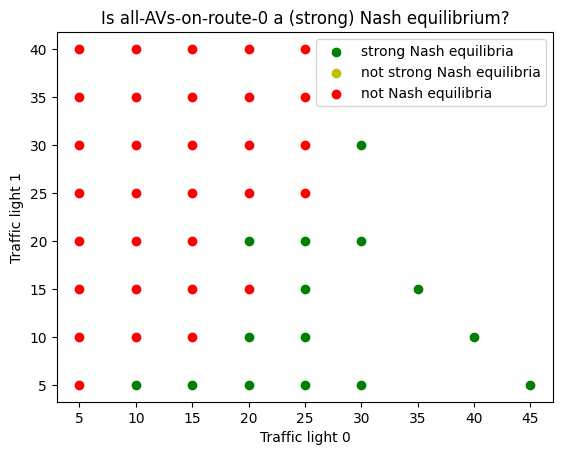

In [20]:
snash_x, snash_y = [], []
nash_x, nash_y = [], []
notnash_x, notnash_y = [], []

for tl_0 in range(5,50,5):
    for tl_1 in range(5,45,5):
        filename = "reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1, 5, 23)
        try:
            tab_reward = build_rewardtable(filename)
            if nash_equilibrium(id_to_strategy(0)):
                if strong_nash_equilibrium(id_to_strategy(0)):
                    snash_x.append(tl_0)
                    snash_y.append(tl_1)
                else:
                    nash_x.append(tl_0)
                    nash_y.append(tl_1)
            else:
                notnash_x.append(tl_0)
                notnash_y.append(tl_1)
        except:
            x=0

plt.scatter(snash_x, snash_y, color="g", label="strong Nash equilibria")
plt.scatter(nash_x, nash_y, color="y", label="not strong Nash equilibria")
plt.scatter(notnash_x, notnash_y, color="r", label="not Nash equilibria")
plt.xlabel("Traffic light 0")
plt.ylabel("Traffic light 1")
plt.legend()
plt.title("Is all-AVs-on-route-0 a (strong) Nash equilibrium?")
plt.show()

In [17]:
##################### Environment Creation #####################
# params = get_params("params.json")
# print(params[kc.PLOTTER][kc.RECORDS_FOLDER])

# env.start()
###################### Human Learning #####################
#num_episodes = 0
#
#for episode in range(num_episodes):
#    env.step()
#
##################### Mutation #####################
#env.mutation()

In [25]:
## How to check whether a custom active-trafficlight system is a NE and a SNE

tl_list = [(45,5,5,23) if i < 2 else (10,40,5,23) for i in range(11)]

custom_df(tl_list)
tab_reward = build_rewardtable("reward_df_custom.csv")
print(nash_equilibrium(id_to_strategy(0)))
print(strong_nash_equilibrium(id_to_strategy(0)))


True
True


In [36]:
tl_list = [(35,5,5,23) if i < 2 else (20,20,5,23) for i in range(11)]

custom_df(tl_list)
tab_reward = build_rewardtable("reward_df_custom.csv")
print(nash_equilibrium(id_to_strategy(0)))
print(strong_nash_equilibrium(id_to_strategy(0)))

Network with tl_0 = 35, tl_1 = 5, tl_y = 5 and 23 agents has not been run yet. Running...
['<?xml version="1.0" encoding="UTF-8"?>\n', '\n', '<!-- generated on 2025-04-16 16:19:46 by Eclipse SUMO netedit Version 1.22.0\n', '<neteditConfiguration xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:noNamespaceSchemaLocation="http://sumo.dlr.de/xsd/neteditConfiguration.xsd">\n', '\n', '    <input>\n', '        <sumo-net-file value="C:\\Users\\Utilisateur\\Desktop\\projectrouterl\\venv\\Lib\\site-packages\\routerl\\networks\\two_route_trafficlight\\two_route_trafficlight.net.xml"/>\n', '    </input>\n', '\n', '    <output>\n', '        <output-file value="C:\\Users\\Utilisateur\\Desktop\\projectrouterl\\venv\\Lib\\site-packages\\routerl\\networks\\two_route_trafficlight\\two_route_trafficlight.net.xml"/>\n', '    </output>\n', '\n', '    <processing>\n', '        <geometry.min-radius.fix.railways value="false"/>\n', '        <geometry.max-grade.fix value="false"/>\n', '        <offse

In [21]:
tab_reward = build_rewardtable("reward_df_custom.csv")
print(nash_equilibrium(id_to_strategy(0)))
print(strong_nash_equilibrium(id_to_strategy(0)))

True
True


In [ ]:
nash_equilibrium(id_to_strategy(0))